In [1]:
from pathlib import Path

import tomllib

import numpy  as np
import tables as tb
import pandas as pd
import matplotlib.pyplot as plt

from nbtools import auto_plot_style
from nbtools import normhist
from nbtools import normhist2d
from jupyfun import progressbar

from utils import *

In [2]:
%matplotlib inline
auto_plot_style()

In [3]:
path      = Path("/home/gonzalo/data/COLINA/mc/colina/dsipms_2mm/")
filenames = sorted(path.glob("*.h5"))
filename  = filenames[0]
len(filenames)

10

In [4]:
testdf = imgs_from_file(filename)
testdf

,x0,y0,z0,r0,image
event,,,,,
0,-13.039702,22.891704,-5.193165,26.345093,"[[[0, 0, 0, 1, 0, 0, 1, 4, 6, 1], [0, 0, 0, 0,..."
1,-12.371400,-28.369127,-5.172233,30.949296,"[[[1, 1, 4, 1, 0, 1, 0, 0, 0, 0], [1, 0, 4, 2,..."
2,-25.957213,6.479440,-5.159746,26.753693,"[[[0, 1, 1, 7, 13, 21, 12, 8, 10, 2], [0, 0, 4..."
3,-10.571912,18.739216,-5.190626,21.515658,"[[[0, 1, 0, 1, 0, 0, 1, 5, 4, 6], [0, 0, 1, 0,..."
4,-9.177871,9.251302,-5.162716,13.031497,"[[[0, 0, 0, 0, 0, 3, 4, 3, 0, 0], [0, 0, 0, 4,..."
...,...,...,...,...,...
49995,24.112577,-2.542272,-5.190965,24.246227,"[[[0, 0, 0, 0, 0, 1, 0, 0, 0, 0], [0, 0, 0, 0,..."
49996,25.838390,-16.118867,-5.193925,30.453904,"[[[0, 0, 0, 1, 2, 0, 0, 0, 0, 0], [0, 0, 0, 1,..."
49997,11.836709,-16.712709,-5.195716,20.479803,"[[[0, 0, 0, 1, 1, 0, 0, 0, 0, 0], [0, 0, 1, 0,..."


In [12]:
config    = simconfig(filename)
sipm_pos  = sipm_positions(config.sipm_size, config.sipm_gap, config.n_sipm_side)[0]
sipm_x    = sipm_positions(config.sipm_size, config.sipm_gap, config.n_sipm_side)[1]
sipm_y    = sipm_positions(config.sipm_size, config.sipm_gap, config.n_sipm_side)[2]
sipm_x    = gang_array(sipm_x, 2, 2)/4
sipm_y    = gang_array(sipm_y, 2, 2)/4
extents   = sipm_extent   (config.sipm_size, config.sipm_gap, config.n_sipm_side)
ticks     = np.arange(-15, 16, 10) if config.el_diam==32 else np.arange(-30, 31, 15)

rmax   = config.el_diam/2
rbins  = np.linspace(    0, rmax, 81)
xybins = np.linspace(-rmax, rmax, 81)
drbins = np.linspace(    0, rmax, 81)

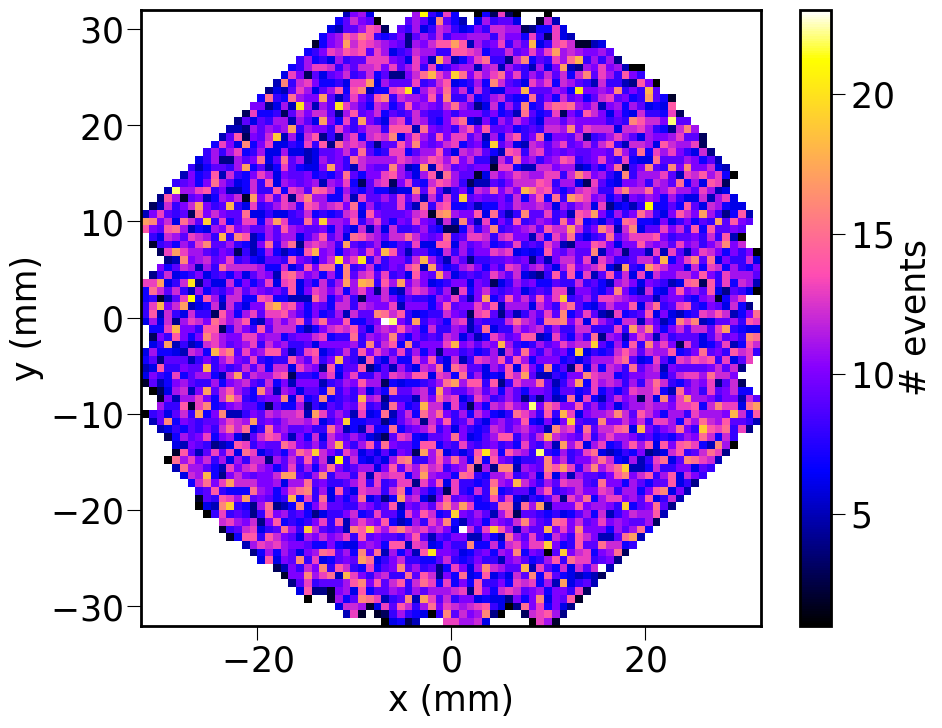

In [13]:
y = plt.hist2d(testdf.x0, testdf.y0, (xybins, xybins), cmin=1)[0]
plt.xlabel("x (mm)")
plt.ylabel("y (mm)")
plt.colorbar().set_label("# events")
evt_per_bin = y[y>0].mean()

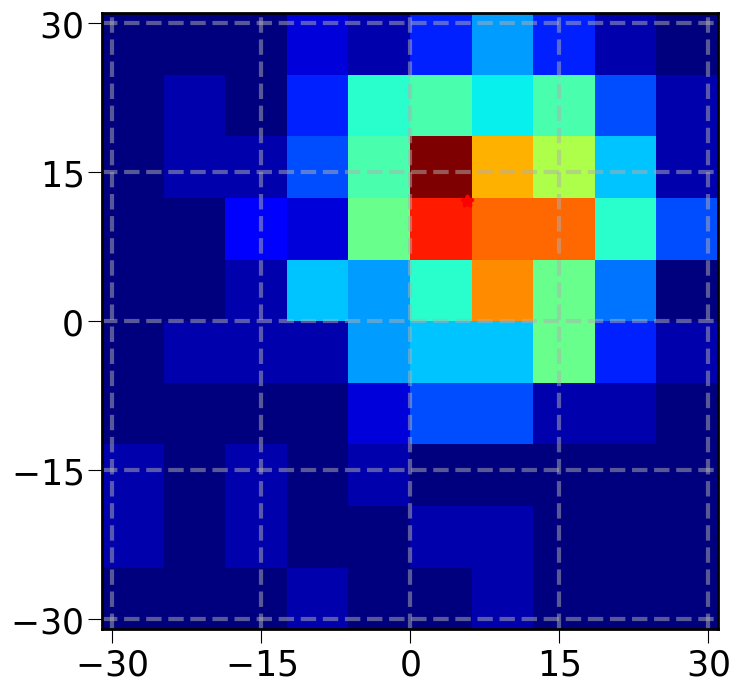

In [14]:
row = testdf.iloc[15]
img = row.image[0].T
x0  = row.x0
y0  = row.y0
plt.imshow(img, origin="lower", extent=extents, cmap="jet")
plt.scatter([x0], [y0], 50, marker="*", color="r")
plt.xticks(ticks)
plt.yticks(ticks)
plt.grid()

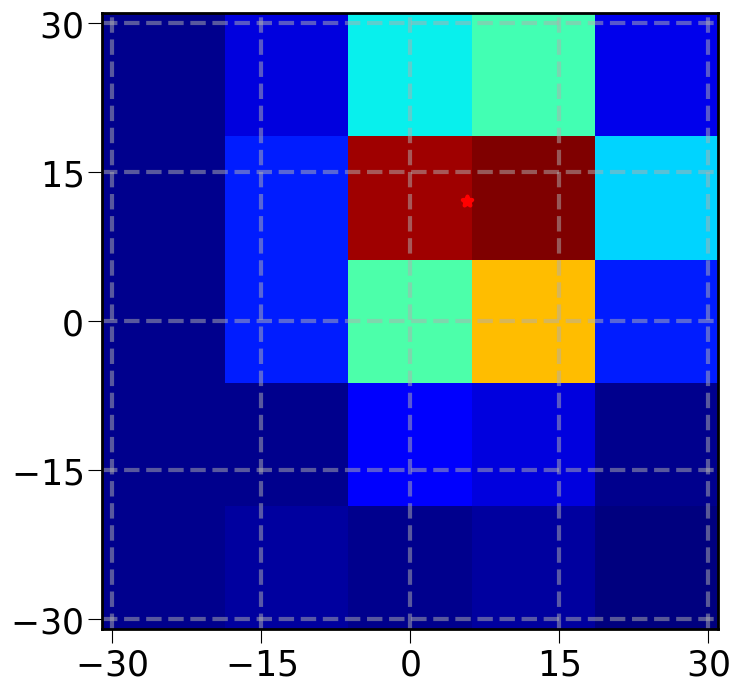

In [17]:
row = testdf.iloc[15:16]
row = gang_image(row, 2, 2).iloc[0]
img = row.image[0].T
x0  = row.x0
y0  = row.y0
plt.imshow(img, origin="lower", extent=extents, cmap="jet")
plt.scatter([x0], [y0], 50, marker="*", color="r")
plt.xticks(ticks)
plt.yticks(ticks)
plt.grid()

# Barycenter

In [11]:
df = testdf.groupby(level=0).apply(gang_image, 2, 2)
df = (df.groupby(level=0)
        .apply(barycenter, sipm_x, sipm_y)
        .join(df.drop(columns=["image"]))
     )
df.insert(df.shape[1], "dx", df.x - df.x0)
df.insert(df.shape[1], "dy", df.y - df.y0)
df.insert(df.shape[1], "dr", (df.dx**2 + df.dy**2)**0.5)

reco_bb = df

In [12]:
reco_bb

,,x,y,x0,y0,z0,r0,dx,dy,dr
event,event,,,,,,,,,
0,0,-10.720833,16.748611,-13.039702,22.891704,-5.193165,26.345093,2.318868,-6.143093,6.566182
1,1,-6.987845,-17.469613,-12.371400,-28.369127,-5.172233,30.949296,5.383555,10.899514,12.156565
2,2,-16.986301,4.416438,-25.957213,6.479440,-5.159746,26.753693,8.970912,-2.063002,9.205066
3,3,-10.284706,16.338824,-10.571912,18.739216,-5.190626,21.515658,0.287206,-2.400392,2.417513
4,4,-7.722807,8.157895,-9.177871,9.251302,-5.162716,13.031497,1.455064,-1.093407,1.820096
...,...,...,...,...,...,...,...,...,...,...
49995,49995,16.783838,1.169024,24.112577,-2.542272,-5.190965,24.246227,-7.328738,3.711296,8.214872
49996,49996,17.972152,-11.536709,25.838390,-16.118867,-5.193925,30.453904,-7.866238,4.582158,9.103509
49997,49997,12.432376,-14.828198,11.836709,-16.712709,-5.195716,20.479803,0.595667,1.884510,1.976411


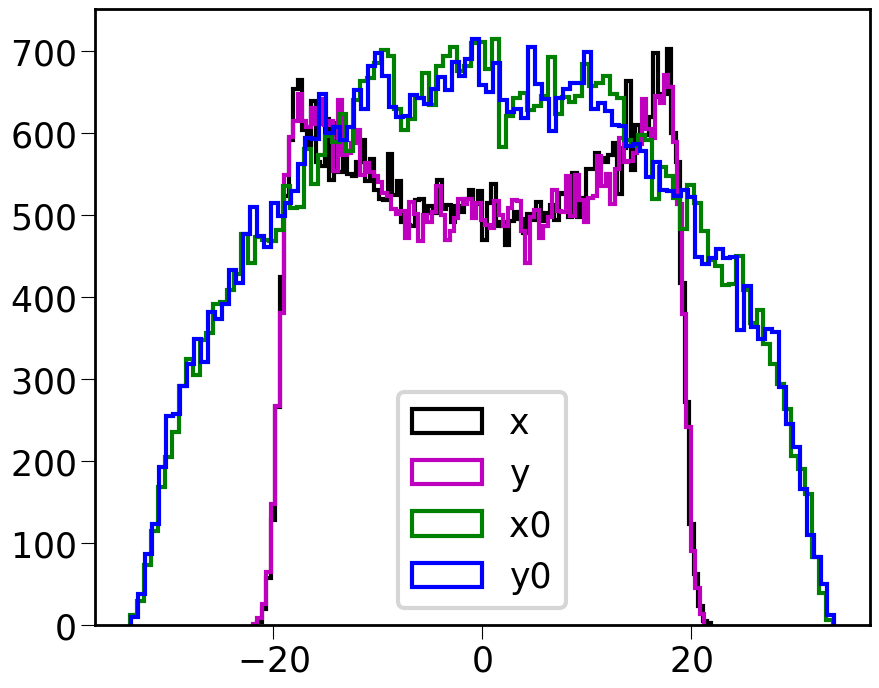

In [13]:
plt.hist(reco_bb.x , 101, histtype="step", label="x");
plt.hist(reco_bb.y , 101, histtype="step", label="y");
plt.hist(reco_bb.x0, 101, histtype="step", label="x0");
plt.hist(reco_bb.y0, 101, histtype="step", label="y0");
plt.legend()

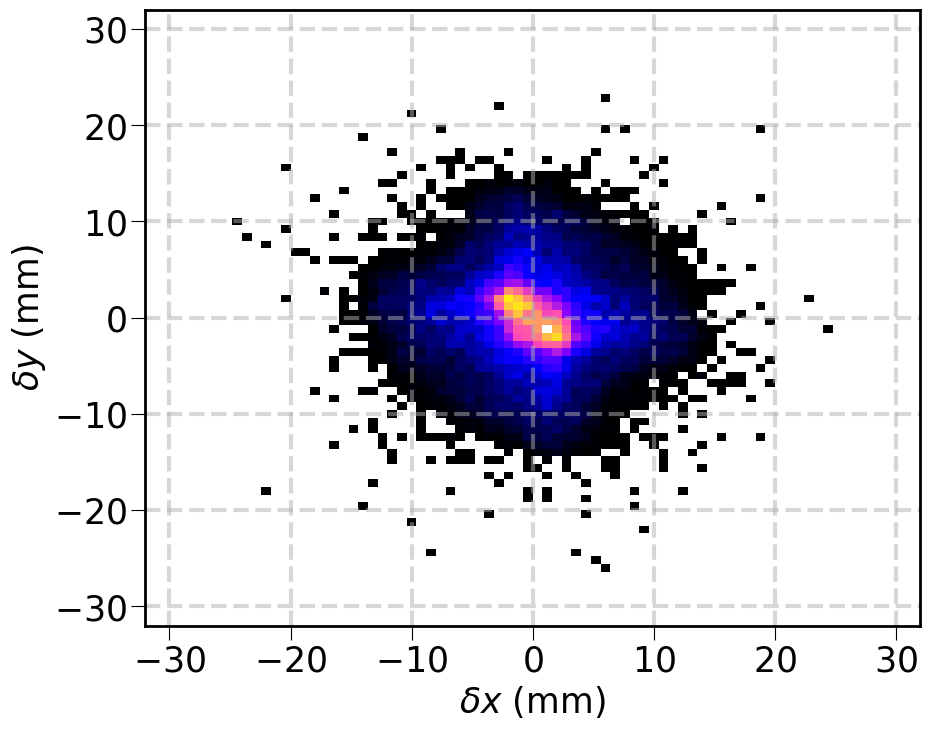

In [14]:
normhist2d(reco_bb.dx, reco_bb.dy, (drbins*2-drbins.max(),)*2)
plt.xlabel("$\delta x$ (mm)")
plt.ylabel("$\delta y$ (mm)")
plt.grid()

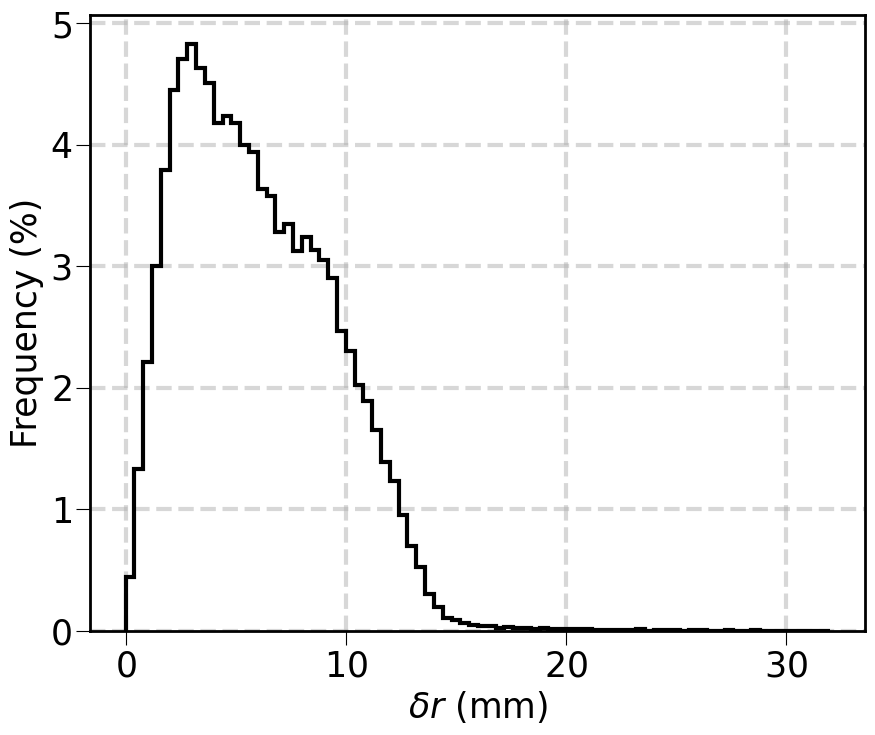

In [15]:
normhist(reco_bb.dr, drbins)
plt.xlabel("$\delta r$ (mm)")
plt.ylabel("Frequency (%)")
plt.grid()

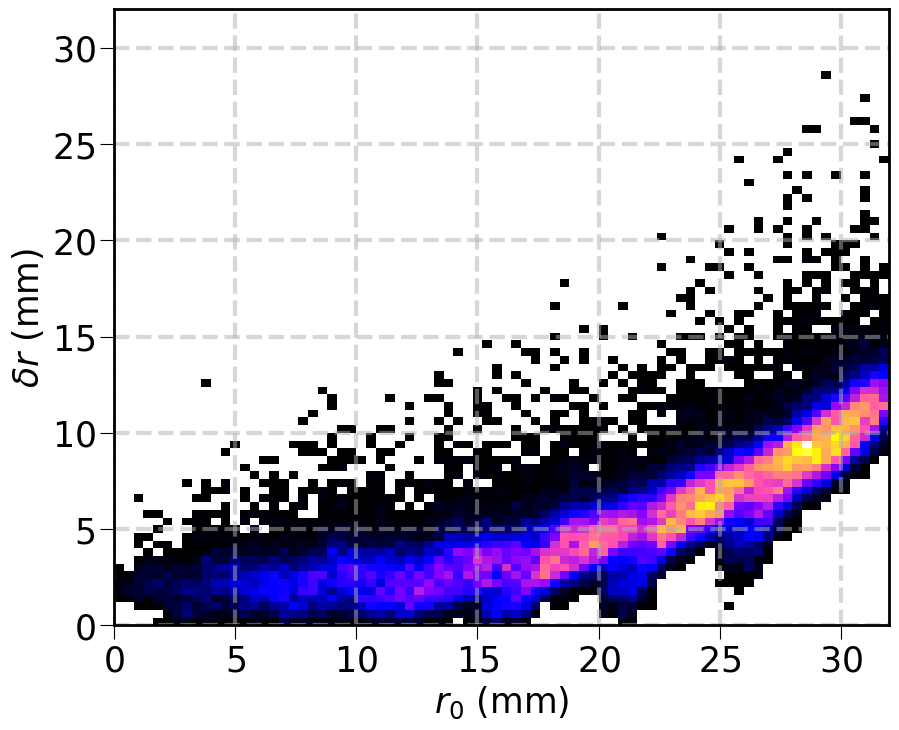

In [16]:
normhist2d(reco_bb.r0, reco_bb.dr, (rbins, drbins))
plt.xlabel("$r_0$ (mm)")
plt.ylabel("$\delta r$ (mm)")
plt.grid()

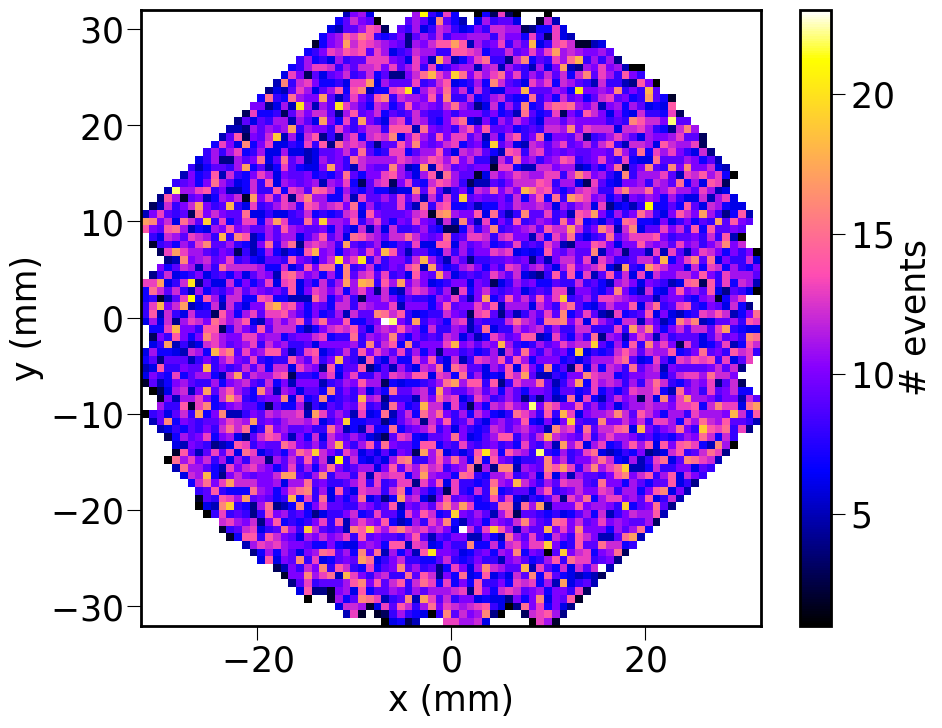

In [17]:
y = plt.hist2d(reco_bb.x0, reco_bb.y0, (xybins, xybins), cmin=1)[0]
plt.xlabel("x (mm)")
plt.ylabel("y (mm)")
plt.colorbar().set_label("# events")
evt_per_bin = y[y>0].mean()

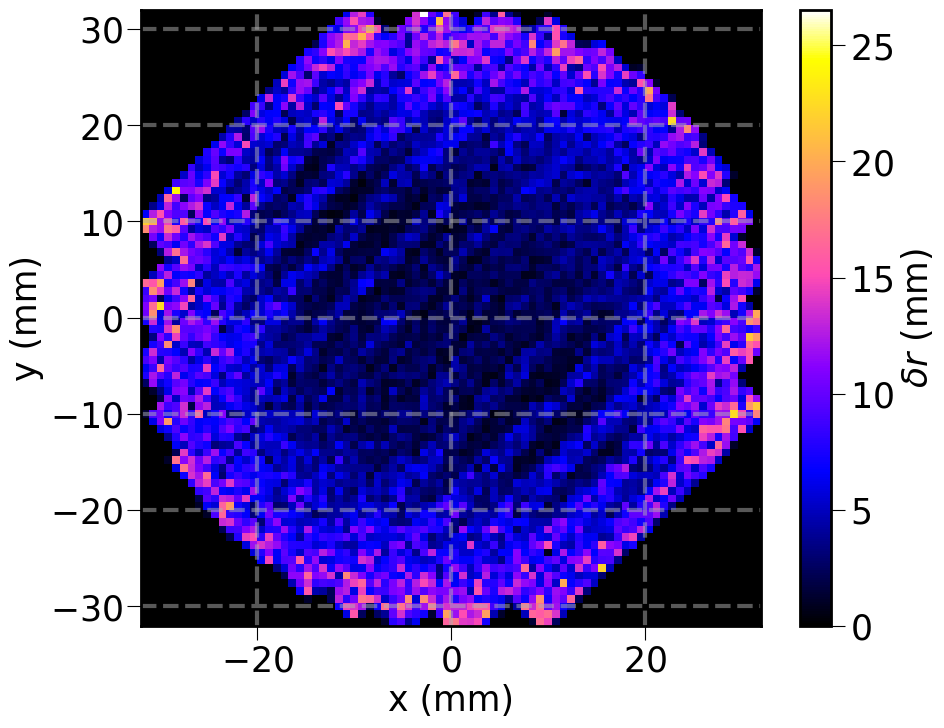

In [18]:
plt.hist2d(reco_bb.x0, reco_bb.y0, (xybins, xybins), weights=reco_bb.dr/evt_per_bin)
plt.xlabel("x (mm)")
plt.ylabel("y (mm)")
plt.colorbar().set_label("$\delta r$ (mm)")
plt.grid()

# NN

In [19]:
import torch
import torch.nn as nn
import torch.optim as optim

In [20]:
class Linear(nn.Module):
    def __init__(self, nx, ny):
        super().__init__()
        self.flatten = nn.Flatten()
        self.l1      = nn.Linear(nx*ny, 64, dtype=float)
        self.l2      = nn.Linear(64, 32, dtype=float)
        self.l3      = nn.Linear(32, 2, dtype=float)
        
    def forward(self, x):
        x = self.flatten(x)
        x = torch.relu(self.l1(x))
        x = torch.relu(self.l2(x))
        x =            self.l3(x)
        return x

In [25]:
data = pd.concat([imgs_from_file(filename) for filename in filenames[:2]])
data

,x0,y0,z0,r0,image
event,,,,,
0,-13.039702,22.891704,-5.193165,26.345093,"[[[0, 0, 0, 1, 0, 0, 1, 4, 6, 1], [0, 0, 0, 0,..."
1,-12.371400,-28.369127,-5.172233,30.949296,"[[[1, 1, 4, 1, 0, 1, 0, 0, 0, 0], [1, 0, 4, 2,..."
2,-25.957213,6.479440,-5.159746,26.753693,"[[[0, 1, 1, 7, 13, 21, 12, 8, 10, 2], [0, 0, 4..."
3,-10.571912,18.739216,-5.190626,21.515658,"[[[0, 1, 0, 1, 0, 0, 1, 5, 4, 6], [0, 0, 1, 0,..."
4,-9.177871,9.251302,-5.162716,13.031497,"[[[0, 0, 0, 0, 0, 3, 4, 3, 0, 0], [0, 0, 0, 4,..."
...,...,...,...,...,...
49995,-19.995488,19.089280,-5.172577,27.644532,"[[[0, 1, 0, 0, 2, 5, 4, 4, 7, 2], [0, 1, 0, 0,..."
49996,-7.181711,-29.324289,-5.186872,30.190908,"[[[0, 0, 0, 0, 0, 0, 0, 0, 0, 0], [4, 4, 1, 1,..."
49997,-9.324914,-15.696704,-5.186848,18.257616,"[[[0, 1, 5, 8, 3, 0, 1, 0, 0, 0], [4, 9, 13, 1..."


In [38]:
nfiles    = len(filenames)
train     = pd.concat([imgs_from_file(filename) for filename in filenames[:nfiles//2 ]]).reset_index().groupby(level=0).apply(gang_image, 2, 2)
test      = pd.concat([imgs_from_file(filename) for filename in filenames[ nfiles//2:]]).reset_index().groupby(level=0).apply(gang_image, 2, 2)
n_train   = len(train)
n_test    = len(test)
img_train = np.concatenate(train.image.values).astype(float)
img_test  = np.concatenate(test .image.values).astype(float)
pos_train = train.loc[:, "x0 y0".split()].values
pos_test  = test .loc[:, "x0 y0".split()].values

img_train = torch.tensor(img_train)
img_test  = torch.tensor(img_test )
pos_train = torch.tensor(pos_train)
pos_test  = torch.tensor(pos_test )

In [43]:
model     = Linear(config.n_sipm_side//2, config.n_sipm_side//2)
loss_f    = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

In [44]:
epochs = 500
batch_size = 32
batch_size = 1000

losses = []
for epoch in progressbar(range(epochs)):
    model.train()  # Set the model to training mode
    permutation = torch.randperm(img_train.size(0))  # Shuffle the dataset

    for i in range(0, img_train.size(0), batch_size):
        # Get the next batch
        indices = permutation[i:i + batch_size]
        imgs, pos = img_train[indices], pos_train[indices]

        optimizer.zero_grad()
        outputs = model(imgs)
        loss    = loss_f(outputs, pos)

        loss.backward()
        optimizer.step()
        losses.append(loss.detach().numpy())

Item 500 of 500 | 0.27 s/item | ETA 0.0 min | Ellapsed 2.3 min


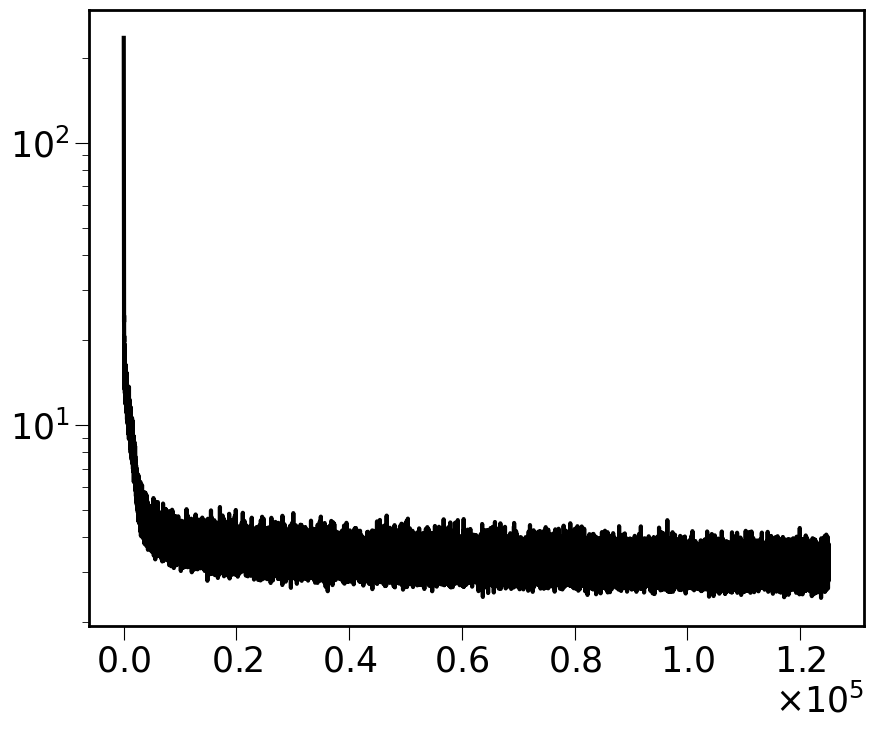

In [45]:
plt.plot(losses)
plt.yscale("log")
plt.show()

In [46]:
model.eval()  # Set the model to evaluation mode
pos_model = model(img_test).detach().numpy()
pos_test_ = pos_test.detach().numpy()

df = test.filter("x0 y0 r0".split())
df = df.assign(  x = pos_model.T[0]
              ,  y = pos_model.T[1]
              , dx = pos_model.T[0] - df.x0
              , dy = pos_model.T[1] - df.y0
              , dr = np.sum((pos_model - pos_test_)**2, axis=1)**0.5
              )

reco_nn = df

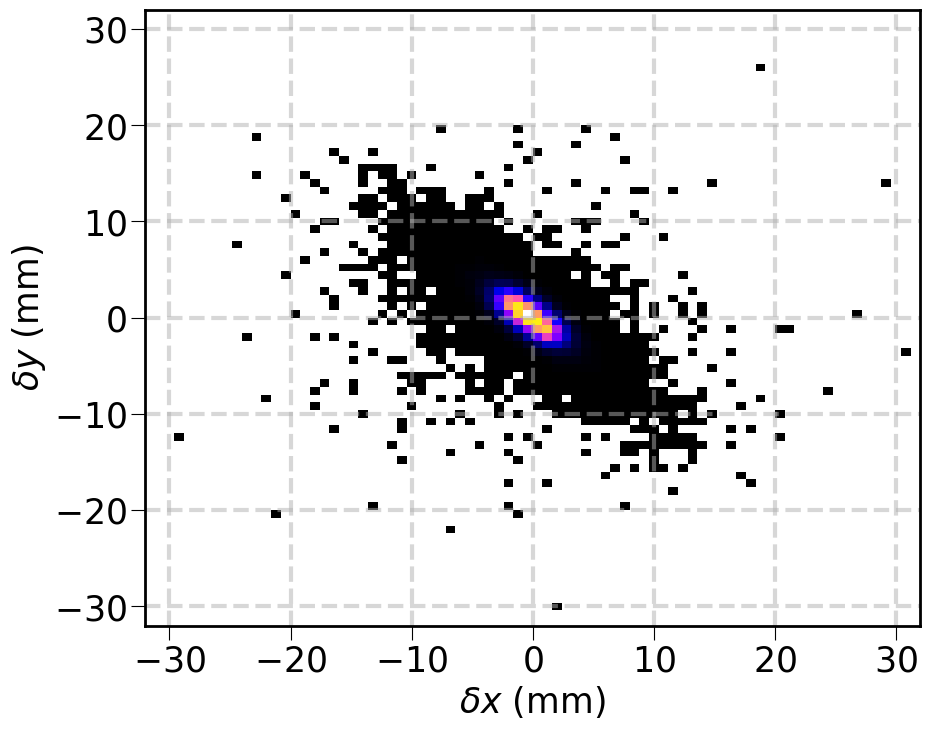

In [47]:
normhist2d(reco_nn.dx, reco_nn.dy, (drbins*2-drbins.max(),)*2)
plt.xlabel("$\delta x$ (mm)")
plt.ylabel("$\delta y$ (mm)")
plt.grid()

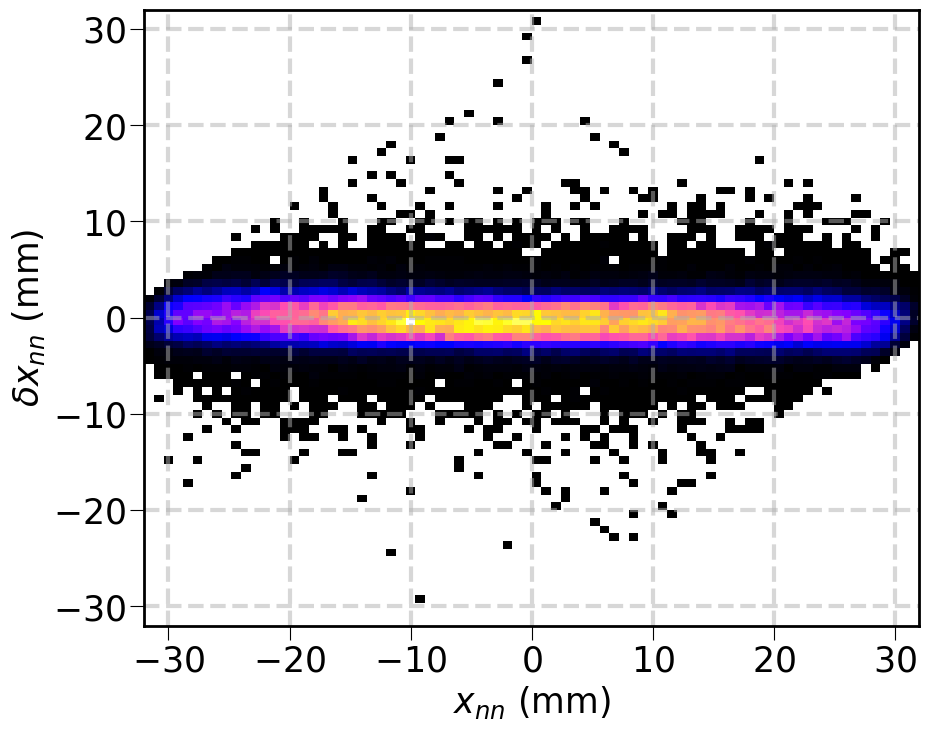

In [48]:
df = reco_nn
#df = df.loc[df.y.abs() < 1]
#df = df.loc[df.x>12]
normhist2d(df.x, df.dx, (xybins, xybins))
plt.xlabel("$x_{nn}$ (mm)")
plt.ylabel("$\delta x_{nn}$ (mm)")
plt.grid()

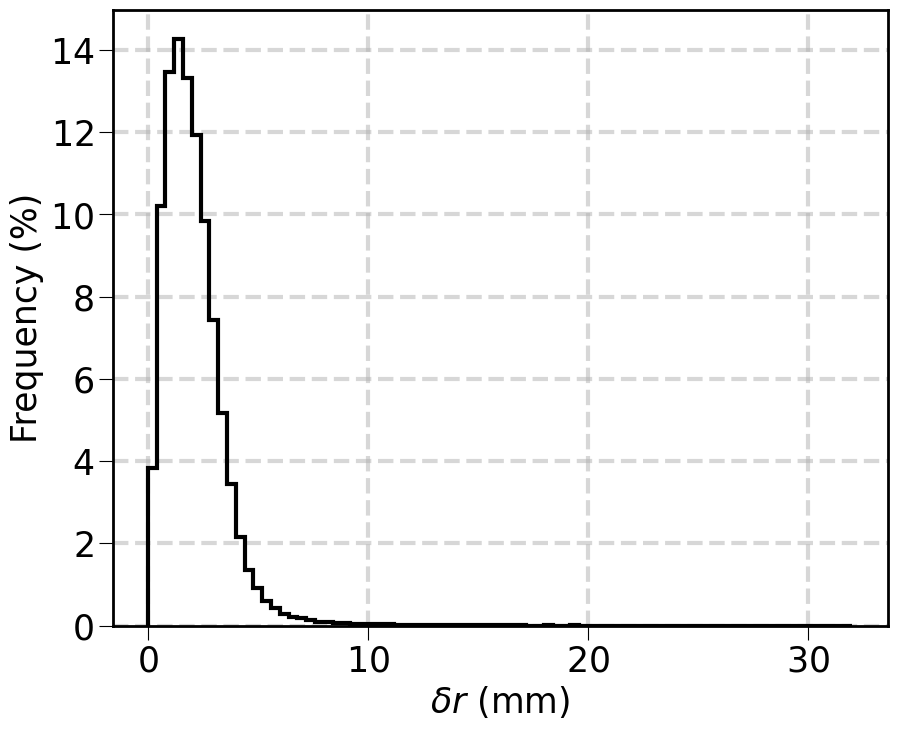

In [49]:
normhist(reco_nn.dr, drbins)
plt.xlabel("$\delta r$ (mm)")
plt.ylabel("Frequency (%)")
plt.grid()
plt.show()

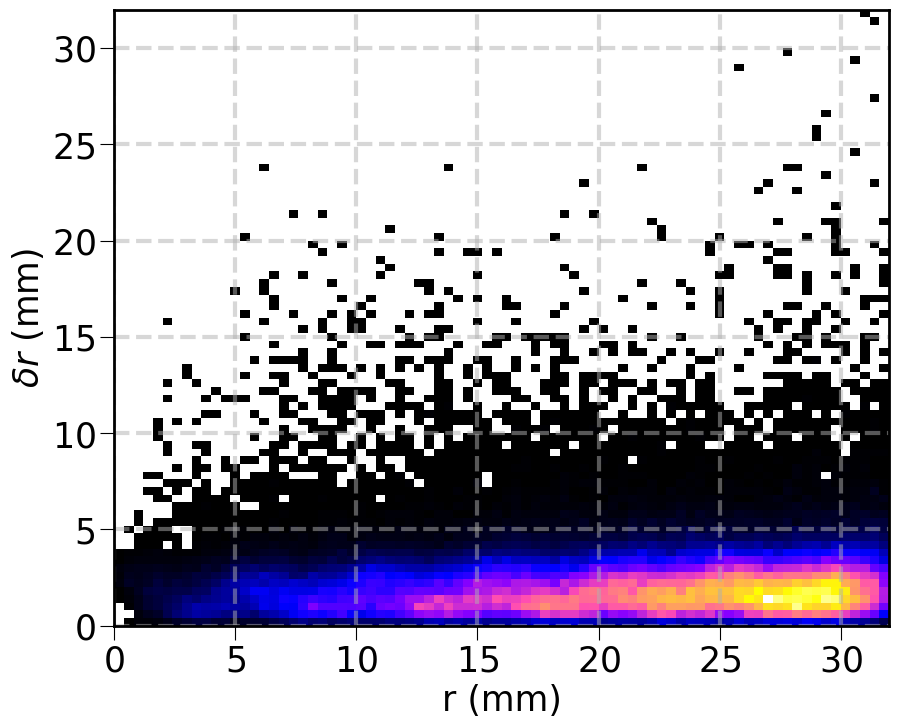

In [50]:
normhist2d(reco_nn.r0, reco_nn.dr, (rbins, drbins))
plt.xlabel("r (mm)")
plt.ylabel("$\delta r$ (mm)")
plt.grid()
plt.show()

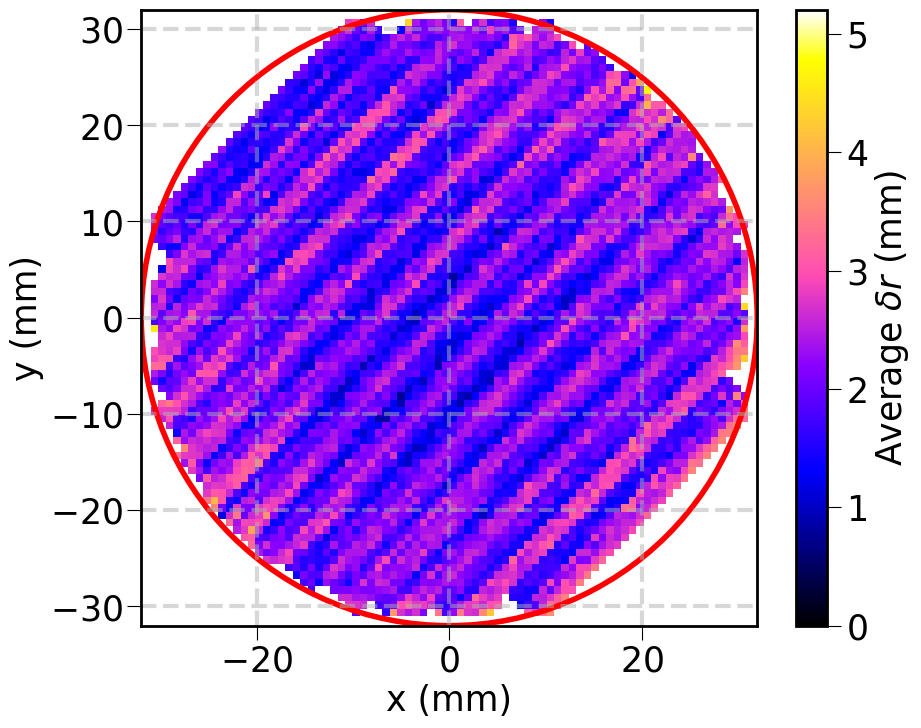

In [51]:
evts = np.histogram2d(reco_nn.x0, reco_nn.y0, (xybins, xybins))[0]
errs = np.histogram2d(reco_nn.x0, reco_nn.y0, (xybins, xybins), weights=reco_nn.dr)[0]
errs = errs / np.clip(evts, 1, None)
errs = np.where(errs>0, errs, np.nan)
plt.imshow(errs.T, origin="lower", vmin=0, vmax=2.5*np.median(errs[errs>0]), extent=extents)
plt.xlabel("x (mm)")
plt.ylabel("y (mm)")
plt.colorbar().set_label("Average $\delta r$ (mm)")
draw_el(plt.gca(), rmax)
plt.grid()

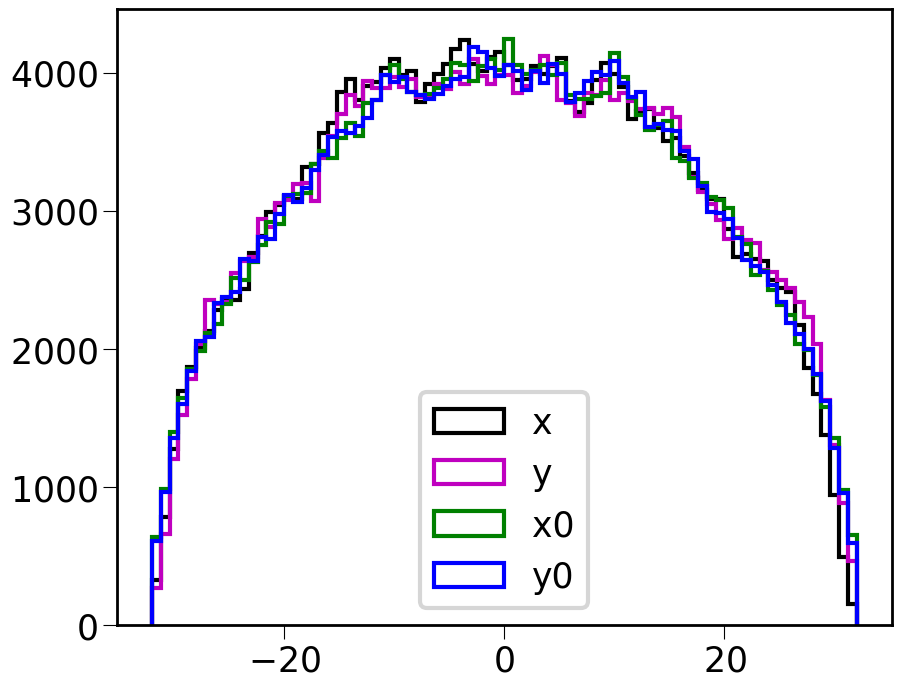

In [52]:
plt.hist(reco_nn.x , xybins, histtype="step", label="x");
plt.hist(reco_nn.y , xybins, histtype="step", label="y");
plt.hist(reco_nn.x0, xybins, histtype="step", label="x0");
plt.hist(reco_nn.y0, xybins, histtype="step", label="y0");
plt.legend()

In [53]:
reco_nn

,,x0,y0,r0,x,y,dx,dy,dr
0,0,8.553725,-8.101924,11.781655,8.166304,-7.523517,-0.387421,0.578408,0.696168
1,1,-3.186798,-10.626610,11.094166,-2.432991,-11.636994,0.753808,-1.010384,1.260596
2,2,15.292028,22.454785,27.167324,13.749761,25.558665,-1.542267,3.103881,3.465929
3,3,5.867695,-17.956789,18.891165,6.115185,-16.639946,0.247490,1.316843,1.339898
4,4,10.729004,0.469274,10.739262,9.950484,1.500406,-0.778519,1.031132,1.292024
...,...,...,...,...,...,...,...,...,...
249925,249925,0.529835,24.320109,24.325880,0.420290,25.753204,-0.109545,1.433095,1.437276
249926,249926,-9.047716,7.023841,11.454061,-10.029982,7.451142,-0.982266,0.427301,1.071183
249927,249927,21.023403,20.722099,29.519296,20.495440,17.611400,-0.527962,-3.110699,3.155185
249928,249928,-22.845147,16.090516,27.942896,-23.497520,17.525764,-0.652372,1.435248,1.576556


In [54]:
output = filenames[0].parent
output = output.parent / (output.stem + "_ganging_reco_summary.h5")
reco_nn.to_hdf(output, key="/data", complib="zlib", complevel=4, mode="w")

In [55]:
import datetime
print(f"Last execution: {datetime.datetime.now()}")

Last execution: 2026-03-04 11:26:08.753012
